<a href="https://colab.research.google.com/github/Tselovanska/machine-learning-course/blob/main/HW_2_4_%D0%90%D0%BB%D0%B3%D0%BE%D1%80%D0%B8%D1%82%D0%BC%D0%B8_%D0%B1%D1%83%D1%81%D1%82%D0%B8%D0%BD%D0%B3%D1%83.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

В цьому домашньому завданні ми знову працюємо з даними з нашого змагання ["Bank Customer Churn Prediction (DLU Course)"](https://www.kaggle.com/t/7c080c5d8ec64364a93cf4e8f880b6a0).

Тут ми побудуємо рішення задачі класифікації з використанням алгоритмів бустингу: XGBoost та LightGBM, а також використаємо бібліотеку HyperOpt для оптимізації гіперпараметрів.

0. Зчитайте дані `train.csv` в змінну `raw_df` та скористайтесь наведеним кодом нижче аби розділити дані на трнувальні та валідаційні і розділити дані на ознаки з матириці Х та цільову змінну. Назви змінних `train_inputs, train_targets, train_inputs, train_targets` можна змінити на ті, які Вам зручно.

  Наведений скрипт - частина отриманого мною скрипта для обробки даних. Ми тут не викнуємо масштабування та обробку категоріальних змінних, бо хочемо це делегувати алгоритмам, які будемо використовувати. Якщо щось не розумієте в наведених скриптах, рекомендую розібратись: навичка читати код - важлива складова роботи в машинному навчанні.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from typing import Tuple, Dict, Any, List

from google.colab import drive
drive.mount('/content/drive')


import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from xgboost import XGBClassifier
import xgboost as xgb

from sklearn.metrics import classification_report, roc_auc_score, accuracy_score


sys.path.append('/content/drive/MyDrive/Colab Notebooks')

from process_bank_churn import preprocess_data,preprocess_new_data

folder_path = '/content/drive/MyDrive/kaggle/DLU_Course_5/'
file_name = 'train.csv'

from hyperopt import fmin, tpe, hp, STATUS_OK, Trials


import lightgbm as lgb

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
def separate_inputs_targets(df: pd.DataFrame, input_cols: list, target_col: str) -> Tuple[pd.DataFrame, pd.Series]:
    """
    Separate inputs and targets from the dataframe.

    Args:
        df (pd.DataFrame): The dataframe.
        input_cols (list): List of input columns.
        target_col (str): Target column.

    Returns:
        Tuple[pd.DataFrame, pd.Series]: DataFrame of inputs and Series of targets.
    """
    inputs = df[input_cols].copy()
    targets = df[target_col].copy()
    return inputs, targets

In [3]:
def split_data_stratified(
    df: pd.DataFrame,
    target_col: str,
    test_size: float = 0.2,
    random_state: int = 42
) -> Dict[str, pd.DataFrame]:
    """
    Split a dataframe into train/val sets, preserving the class ratio of target_col.

    Args:
        df (pd.DataFrame): Dataframe to split.
        target_col (str): Column to stratify on (imbalanced target).
        test_size (float): Fraction of data allocated to validation.
        random_state (int): Seed for reproducibility.

    Returns:
        Dict[str, pd.DataFrame]: {'train': train_df, 'val': val_df}.
    """
    train_df, val_df = train_test_split(
        df, test_size=test_size, random_state=random_state, stratify=df[target_col]
    )
    return {'train': train_df, 'val': val_df}


def create_inputs_targets(
    df_dict: Dict[str, pd.DataFrame],
    input_cols: List[str],
    target_col: str
) -> Dict[str, Any]:
    """
    Split each dataframe in df_dict into inputs (features) and targets.

    Args:
        df_dict (Dict[str, pd.DataFrame]): {'train': train_df, 'val': val_df}.
        input_cols (List[str]): Feature column names.
        target_col (str): Target column name.

    Returns:
        Dict[str, Any]: {'train_inputs', 'train_targets', 'val_inputs', 'val_targets'}.
    """
    data = {}
    for split in df_dict:
        data[f'{split}_inputs'] = df_dict[split][input_cols].copy()
        data[f'{split}_targets'] = df_dict[split][target_col].copy()
    return data

In [4]:
raw_df = pd.read_csv(folder_path + 'train.csv')
input_cols = [c for c in raw_df.columns if c not in ['ID', 'CustomerId', 'Surname', 'Exited']]
target_col = 'Exited'

result = split_data_stratified(raw_df, 'Exited')
train, val = result['train'], result['val']

data = create_inputs_targets({'train': train, 'val': val}, input_cols, target_col)

In [5]:
X_train = data['train_inputs']
train_targets = data['train_targets']
X_val = data['val_inputs']
val_targets = data['val_targets']


1. В тренувальному та валідаційному наборі перетворіть категоріальні ознаки на тип `category`. Можна це зробити двома способами:
 1. `df[col_name].astype('category')`, як було продемонстровано в лекції
 2. використовуючи метод `pd.Categorical(df[col_name])`

In [6]:
cat_features = X_train.select_dtypes(include='object').columns
X_train[cat_features] = X_train[cat_features].astype('category')
X_val[cat_features] = X_val[cat_features].astype('category')


2. Навчіть на отриманих даних модель `XGBoostClassifier`. Параметри алгоритму встановіть на свій розсуд, ми далі будемо їх тюнити. Рекомендую тренувати не дуже складну модель.

  Опис всіх конфігураційних параметрів XGBoostClassifier - тут https://xgboost.readthedocs.io/en/stable/parameter.html#global-config

  **Важливо:** зробіть такі налаштування `XGBoostClassifier` аби він самостійно обробляв незаповнені значення в даних і обробляв категоріальні колонки.

  Можна також, якщо працюєте в Google Colab, увімкнути можливість використання GPU (`Runtime -> Change runtime type -> T4 GPU`) і встановити параметр `device='cuda'` в `XGBoostClassifier` для пришвидшення тренування бустинг моделі.
  
  Після тренування моделі
  1. Виміряйте точність з допомогою AUROC на тренувальному та валідаційному наборах.
  2. Зробіть висновок про отриману модель: вона хороша/погана, чи є high bias/high variance?
  3. Порівняйте якість цієї моделі з тою, що ви отрмали з використанням DecisionTrees раніше. Чи вийшло покращити якість?

In [7]:
xgb_clf = XGBClassifier(
    max_depth=3,
    n_estimators=50,
    enable_categorical=True,  # для категорійних ознак
    use_label_encoder=False,  # щоб уникнути попереджень, якщо використовуєте нові версії XGBoost
    missing=np.nan,  # явне вказування пропущених значень
    device='cuda'
)

xgb_clf.fit(X_train, train_targets)

train_pred = xgb_clf.predict(X_train)
val_pred = xgb_clf.predict(X_val)

train_auroc = roc_auc_score(train_targets, xgb_clf.predict_proba(X_train)[:, 1])
val_auroc = roc_auc_score(val_targets, xgb_clf.predict_proba(X_val)[:, 1])

print(classification_report(train_targets, train_pred, digits=4))
print(classification_report(val_targets, val_pred, digits=4))

print(f'Train AUROC: {train_auroc:.4f}')
print(f'Val AUROC: {val_auroc:.4f}')
print(f'Difference: {train_auroc - val_auroc:.4f}')



/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [10:25:25] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


              precision    recall  f1-score   support

         0.0     0.9252    0.9666    0.9455      9558
         1.0     0.8416    0.6941    0.7608      2442

    accuracy                         0.9112     12000
   macro avg     0.8834    0.8304    0.8531     12000
weighted avg     0.9082    0.9112    0.9079     12000

              precision    recall  f1-score   support

         0.0     0.9193    0.9582    0.9383      2390
         1.0     0.8035    0.6705    0.7310       610

    accuracy                         0.8997      3000
   macro avg     0.8614    0.8143    0.8347      3000
weighted avg     0.8958    0.8997    0.8962      3000

Train AUROC: 0.9469
Val AUROC: 0.9354
Difference: 0.0116


/usr/local/lib/python3.12/dist-packages/xgboost/core.py:553: UserWarning: [10:25:26] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


Значення набагато вищі відносно попередніх спроб та підходів. Найбільше значення до цього було отримане за допомогою поліномів - 0.921

3. Використовуючи бібліотеку `Hyperopt` і приклад пошуку гіперпараметрів для `XGBoostClassifier` з лекції знайдіть оптимальні значення гіперпараметрів `XGBoostClassifier` для нашої задачі. Задайте свою сітку гіперпараметрів виходячи з тих параметрів, які ви б хотіли перебрати. Поставте кількість раундів в підборі гіперпараметрів рівну **20**.

  **Увага!** Для того, аби скористатись hyperopt, нам треба задати функцію `objective`. В ній ми маємо задати loss - це може будь-яка метрика, але бажано використовувтаи ту, яка цільова в вашій задачі. Чим менший лосс - тим ліпша модель на думку hyperopt. Тож, тут нам треба задати loss - негативне значення AUROC. В лекції ми натомість використовували Accuracy.

  Після успішного завершення пошуку оптимальних гіперпараметрів
    - виведіть найкращі значення гіперпараметрів
    - створіть в окремій зміній `final_clf` модель `XGBoostClassifier` з найкращими гіперпараметрами
    - навчіть модель `final_clf`
    - оцініть якість моделі `final_clf` на тренувальній і валідаційній вибірках з допомогою AUROC.
    - зробіть висновок про якість моделі. Чи стала вона краще порівняно з попереднім пунктом (2) цього завдання?

In [8]:
def objective(params):
    clf = xgb.XGBClassifier(
    n_estimators=int(params['n_estimators']),
        learning_rate=params['learning_rate'],
        max_depth=int(params['max_depth']),
        min_child_weight=params['min_child_weight'],  # Мінімальна сума ваг всіх вибірок, необхідна в кінцевому вузлі
        subsample=params['subsample'],  # Частка вибірок, що використовуються для побудови кожного дерева
        colsample_bytree=params['colsample_bytree'],  # Частка ознак, що використовуються при побудові кожного дерева
        gamma=params['gamma'],  # Мінімальне зменшення втрат, необхідне для виконання поділу
        reg_alpha=params['reg_alpha'],  # Параметр регуляризації L1 (Lasso)
        reg_lambda=params['reg_lambda'],  # Параметр регуляризації L2 (Ridge)
        enable_categorical=True,
        use_label_encoder=False,
        missing=np.nan,
        device='cuda',
        early_stopping_rounds=20
    )

    clf.fit(
        X_train,
        train_targets,
        eval_set=[(X_val, val_targets)],
        verbose=False)
    pred = clf.predict_proba(X_val)[:, 1]
    val_auroc = roc_auc_score(val_targets, pred)



    return {'loss': -val_auroc, 'status': STATUS_OK}

# Простір гіперпараметрів
space = {
    'n_estimators': hp.quniform('n_estimators', 50, 500, 25),
    'learning_rate': hp.uniform('learning_rate', 0.01, 0.3),
    'max_depth': hp.quniform('max_depth', 3, 15, 1),
    'min_child_weight': hp.quniform('min_child_weight', 1, 10, 1),
    'subsample': hp.uniform('subsample', 0.5, 1.0),
    'colsample_bytree': hp.uniform('colsample_bytree', 0.5, 1.0),
    'gamma': hp.uniform('gamma', 0, 0.5),
    'reg_alpha': hp.uniform('reg_alpha', 0, 1),
    'reg_lambda': hp.uniform('reg_lambda', 0, 1)
}

# Оптимізація
trials = Trials()
best = fmin(fn=objective, space=space, algo=tpe.suggest, max_evals=20, trials=trials)

# Перетворення значень гіперпараметрів у кінцеві типи
best['n_estimators'] = int(best['n_estimators'])
best['max_depth'] = int(best['max_depth'])
best['min_child_weight'] = int(best['min_child_weight'])

print("Найкращі гіперпараметри: ", best)

# Навчання фінальної моделі з найкращими гіперпараметрами
final_clf = xgb.XGBClassifier(
    n_estimators=best['n_estimators'],
    learning_rate=best['learning_rate'],
    max_depth=best['max_depth'],
    min_child_weight=best['min_child_weight'],
    subsample=best['subsample'],
    colsample_bytree=best['colsample_bytree'],
    gamma=best['gamma'],
    reg_alpha=best['reg_alpha'],
    reg_lambda=best['reg_lambda'],
    enable_categorical=True,
    use_label_encoder=False,
    missing=np.nan,
    device='cuda',
    early_stopping_rounds=20
)

final_clf.fit(
    X_train, train_targets,
    eval_set=[(X_val, val_targets)],
    verbose=False
)

final_pred_proba = final_clf.predict_proba(X_val)[:, 1]
final_val_auroc = roc_auc_score(val_targets, final_pred_proba)
print("AUROC на валідаційній вибірці: {:.4f}".format(final_val_auroc))

  0%|          | 0/20 [00:00<?, ?trial/s, best loss=?]

/usr/local/lib/python3.12/dist-packages/xgboost/callback.py:385: UserWarning: [10:25:26] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  self.starting_round = model.num_boosted_rounds()



  5%|▌         | 1/20 [00:00<00:10,  1.75trial/s, best loss: -0.9291419164551753]

/usr/local/lib/python3.12/dist-packages/xgboost/callback.py:385: UserWarning: [10:25:26] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  self.starting_round = model.num_boosted_rounds()



 10%|█         | 2/20 [00:01<00:10,  1.78trial/s, best loss: -0.9324768502640784]

...

 95%|█████████▌| 19/20 [00:13<00:00,  1.75trial/s, best loss: -0.9365827560189314]

/usr/local/lib/python3.12/dist-packages/xgboost/callback.py:385: UserWarning: [10:25:39] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  self.starting_round = model.num_boosted_rounds()



100%|██████████| 20/20 [00:13<00:00,  1.46trial/s, best loss: -0.9365827560189314]
Найкращі гіперпараметри:  {'colsample_bytree': np.float64(0.6866635575820365), 'gamma': np.float64(0.13885822094513356), 'learning_rate': np.float64(0.08728777475045486), 'max_depth': 4, 'min_child_weight': 5, 'n_estimators': 350, 'reg_alpha': np.float64(0.9733403614431624), 'reg_lambda': np.float64(0.7486696030667185), 'subsample': np.float64(0.694577099531659)}


/usr/local/lib/python3.12/dist-packages/xgboost/callback.py:385: UserWarning: [10:25:40] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  self.starting_round = model.num_boosted_rounds()


AUROC на валідаційній вибірці: 0.9366


In [9]:
final_pred_proba = final_clf.predict_proba(X_val)[:, 1]
final_val_auroc = roc_auc_score(val_targets, final_pred_proba)

train_pred_proba = final_clf.predict_proba(X_train)[:, 1]
train_auroc = roc_auc_score(train_targets, train_pred_proba)

print(f'Train AUROC: {train_auroc:.4f}')
print(f'Val AUROC: {final_val_auroc:.4f}')
print(f'Difference: {train_auroc - final_val_auroc:.4f}')

Train AUROC: 0.9504
Val AUROC: 0.9366
Difference: 0.0138


Модель хороша, ближче до збалансованої, gap 0.0051 - дуже малий, high variance не спостерігається. Порівняно з попереднім етапом якість покращилась переважно за рахунок кращої регуляризації/стабільності, а не суттєвого зростання AUROC.

4. Навчіть на наших даних модель LightGBM. Параметри алгоритму встановіть на свій розсуд, ми далі будемо їх тюнити. Рекомендую тренувати не дуже складну модель.

  Опис всіх конфігураційних параметрів LightGBM - тут https://lightgbm.readthedocs.io/en/latest/Parameters.html

  **Важливо:** зробіть такі налаштування LightGBM аби він самостійно обробляв незаповнені значення в даних і обробляв категоріальні колонки.

  Аби передати категоріальні колонки в LightGBM - необхідно виявити їх індекси і передати в параметрі `cat_feature=cat_feature_indexes`

  Після тренування моделі
  1. Виміряйте точність з допомогою AUROC на тренувальному та валідаційному наборах.
  2. Зробіть висновок про отриману модель: вона хороша/погана, чи є high bias/high variance?
  3. Порівняйте якість цієї моделі з тою, що ви отрмали з використанням XGBoostClassifier раніше. Чи вийшло покращити якість?

In [10]:
print(lgb.__version__)

4.6.0


In [11]:
cat_feature_indexes = [X_train.columns.get_loc(col) for col in cat_features]

lgb_clf = lgb.LGBMClassifier(
    n_estimators=50,
    max_depth=3,
    random_state=42
)

lgb_clf.fit(
    X_train,
    train_targets,
    categorical_feature=cat_feature_indexes
)

train_pred = lgb_clf.predict(X_train)
val_pred = lgb_clf.predict(X_val)

train_auroc = roc_auc_score(train_targets, lgb_clf.predict_proba(X_train)[:, 1])
val_auroc = roc_auc_score(val_targets, lgb_clf.predict_proba(X_val)[:, 1])

print(classification_report(train_targets, train_pred, digits=4))
print(classification_report(val_targets, val_pred, digits=4))

print(f'Train AUROC: {train_auroc:.4f}')
print(f'Val AUROC: {val_auroc:.4f}')
print(f'Difference: {train_auroc - val_auroc:.4f}')

[LightGBM] [Info] Number of positive: 2442, number of negative: 9558
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001760 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1098
[LightGBM] [Info] Number of data points in the train set: 12000, number of used features: 11
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.203500 -> initscore=-1.364561
[LightGBM] [Info] Start training from score -1.364561
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain:

Модель відпрацювала краще за попередню, gap 0.0028

5. Використовуючи бібліотеку `Hyperopt` і приклад пошуку гіперпараметрів для `LightGBM` з лекції знайдіть оптимальні значення гіперпараметрів `LightGBM` для нашої задачі. Задайте свою сітку гіперпараметрів виходячи з тих параметрів, які ви б хотіли перебрати. Поставте кількість раундів в підборі гіперпараметрів рівну **10**.

  **Увага!** Для того, аби скористатись hyperopt, нам треба задати функцію `objective`. І тут ми також ставимо loss - негативне значення AUROC, як і при пошуці гіперпараметрів для XGBoost. До речі, можна спробувати написати код так, аби в objective передавати лише модель і не писати схожий код двічі :)

  Після успішного завершення пошуку оптимальних гіперпараметрів
    - виведіть найкращі значення гіперпараметрів
    - створіть в окремій зміній `final_lgb_clf` модель `LightGBM` з найкращими гіперпараметрами
    - навчіть модель `final_lgb_clf`
    - оцініть якість моделі `final_lgb_clf` на тренувальній і валідаційній вибірках з допомогою AUROC.
    - зробіть висновок про якість моделі. Чи стала вона краще порівняно з попереднім пунктом (4) цього завдання?

In [12]:
def lgb_objective(params):
    clf = lgb.LGBMClassifier(
        n_estimators=int(params['n_estimators']),
        learning_rate=params['learning_rate'],
        max_depth=int(params['max_depth']),
        num_leaves=int(params['num_leaves']),
        min_child_samples=int(params['min_child_samples']),
        subsample=params['subsample'],
        colsample_bytree=params['colsample_bytree'],
        reg_alpha=params['reg_alpha'],
        reg_lambda=params['reg_lambda'],
        random_state=42,
        verbose=-1
    )

    clf.fit(
        X_train,
        train_targets,
        categorical_feature=cat_feature_indexes
    )

    pred = clf.predict_proba(X_val)[:, 1]
    val_auroc = roc_auc_score(val_targets, pred)

    return {'loss': -val_auroc, 'status': STATUS_OK}


# Простір гіперпараметрів
lgb_space = {
    'n_estimators': hp.quniform('n_estimators', 50, 500, 25),
    'learning_rate': hp.uniform('learning_rate', 0.01, 0.3),
    'max_depth': hp.quniform('max_depth', 3, 15, 1),
    'num_leaves': hp.quniform('num_leaves', 15, 120, 5),
    'min_child_samples': hp.quniform('min_child_samples', 1, 10, 1),
    'subsample': hp.uniform('subsample', 0.5, 1.0),
    'colsample_bytree': hp.uniform('colsample_bytree', 0.5, 1.0),
    'reg_alpha': hp.uniform('reg_alpha', 0, 5),
    'reg_lambda': hp.uniform('reg_lambda', 0, 5),
}

lgb_trials = Trials()

lgb_best_params = fmin(
    fn=lgb_objective,
    space=lgb_space,
    algo=tpe.suggest,
    max_evals=40,
    trials=lgb_trials
)

print('Best params:', lgb_best_params)

100%|██████████| 40/40 [00:29<00:00,  1.36trial/s, best loss: -0.937101996021675]
Best params: {'colsample_bytree': np.float64(0.5329133478657215), 'learning_rate': np.float64(0.061913055198108885), 'max_depth': np.float64(3.0), 'min_child_samples': np.float64(4.0), 'n_estimators': np.float64(250.0), 'num_leaves': np.float64(65.0), 'reg_alpha': np.float64(0.95140262328909), 'reg_lambda': np.float64(2.951467969465753), 'subsample': np.float64(0.5113184580809651)}


In [13]:
final_lgb_clf = lgb.LGBMClassifier(
    n_estimators=int(lgb_best_params['n_estimators']),
    learning_rate=lgb_best_params['learning_rate'],
    max_depth=int(lgb_best_params['max_depth']),
    num_leaves=int(lgb_best_params['num_leaves']),
    min_child_samples=int(lgb_best_params['min_child_samples']),
    subsample=lgb_best_params['subsample'],
    colsample_bytree=lgb_best_params['colsample_bytree'],
    reg_alpha=lgb_best_params['reg_alpha'],
    reg_lambda=lgb_best_params['reg_lambda'],
    random_state=42,
    verbose=-1
)

final_lgb_clf.fit(
    X_train,
    train_targets,
    categorical_feature=cat_feature_indexes
)

train_pred_proba = final_lgb_clf.predict_proba(X_train)[:, 1]
val_pred_proba = final_lgb_clf.predict_proba(X_val)[:, 1]

train_auroc = roc_auc_score(train_targets, train_pred_proba)
val_auroc = roc_auc_score(val_targets, val_pred_proba)

print(f'Train AUROC: {train_auroc:.4f}')
print(f'Val AUROC: {val_auroc:.4f}')
print(f'Difference: {train_auroc - val_auroc:.4f}')

Train AUROC: 0.9455
Val AUROC: 0.9371
Difference: 0.0084


6. Оберіть модель з експериментів в цьому ДЗ і зробіть новий `submission` на Kaggle та додайте код для цього і скріншот скора на публічному лідерборді.
  
  **Напишіть коментар, чому ви обрали саме цю модель?**

  І я вас вітаю - це останнє завдання з цим набором даних 💪 На цьому етапі корисно проаналізувати, які моделі показали себе найкраще і подумати, чому.

In [14]:
test_data = pd.read_csv('test (1).csv')

X_test = test_data[input_cols].copy()
X_test[cat_features] = X_test[cat_features].astype('category')

test_probs = final_lgb_clf.predict_proba(X_test)[:, 1]

submission = pd.DataFrame({
    'id': test_data['id'],
    'Exited': test_probs
})

submission.to_csv('submission.csv', index=False)

LightGBM, оскільки він найкраще себе показав на валідаційних даних

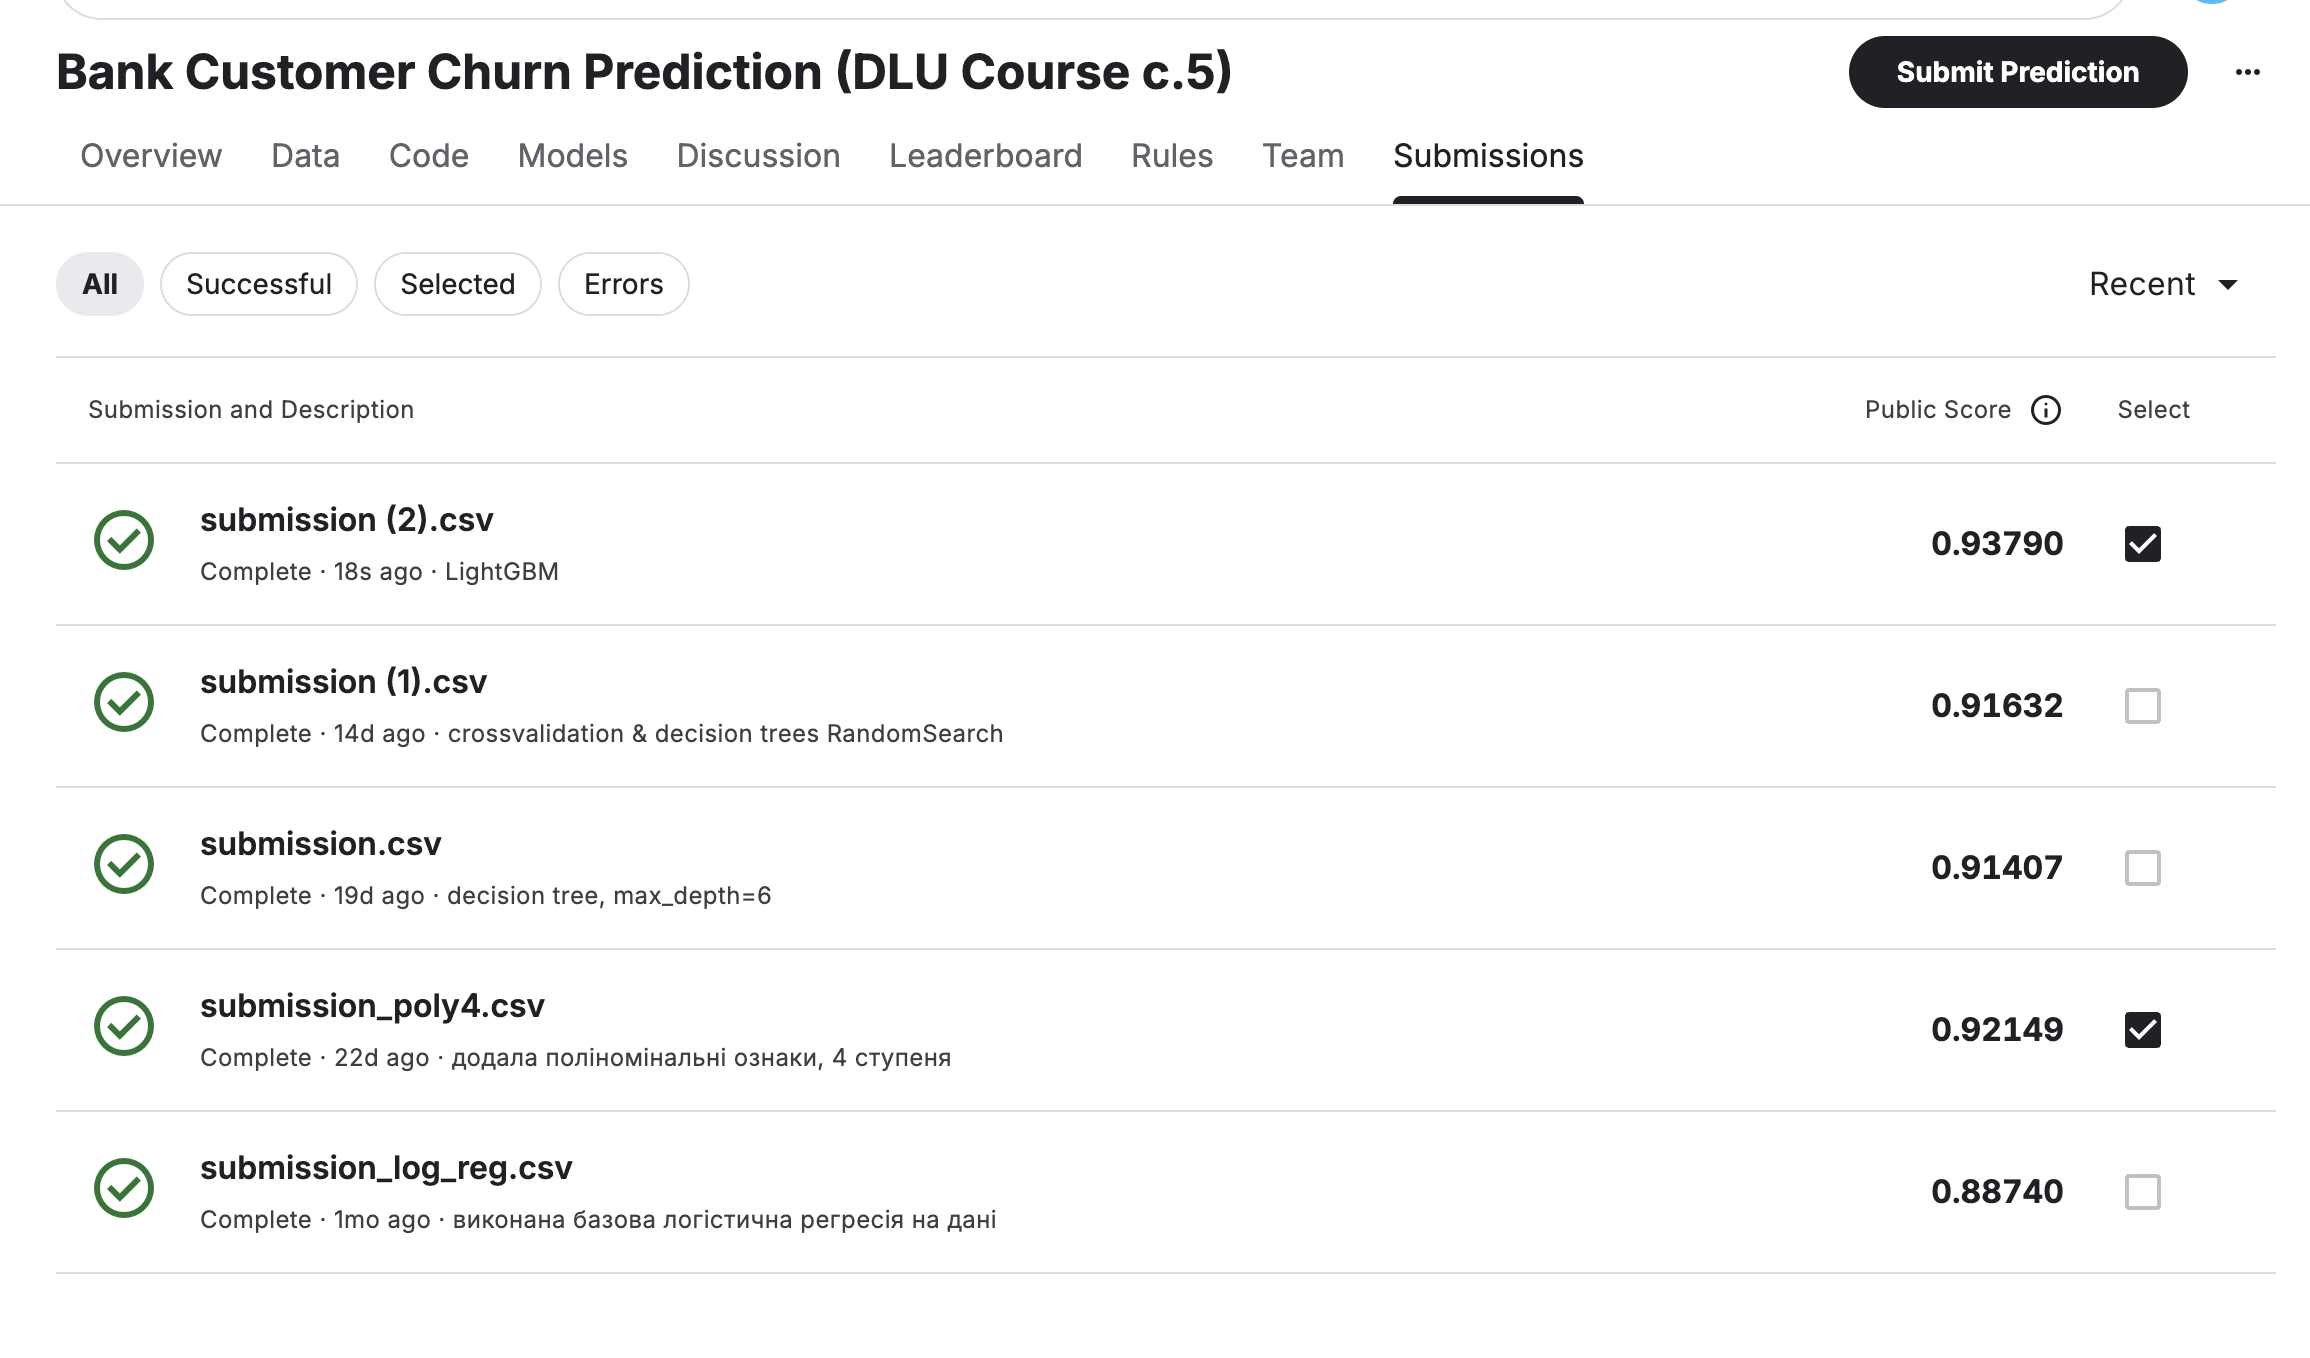